# Análisis y pronóstico de BTC — Programación Funcional
### Trabajo Práctico Final · Cátedra Javier Epeloa

**Dataset:** `btc-timeseries.json` — 365 observaciones diarias consecutivas de Bitcoin (precio promedio diario entre máx y mín), sin datos faltantes.

**¿Qué hacemos acá?**
Como el profe nos aclaró que para la entrega final **no podemos usar Machine Learning**, descartamos el modelo de Gradient Boosting y scikit-learn. En su lugar, armamos dos modelos determinísticos bajo el paradigma funcional que no sean una recta ni un polinomio de juguete:

1. **Función no lineal (Tanh + Fourier):** Ajuste global con tangente hiperbólica y armónicos trigonométricos usando `curve_fit`.
2. **Modelo de Ventana Móvil (W=7 días):** Estimador funcional puro que calcula el promedio de la última semana usando `reduce` sobre tuplas inmutables.

Ambos los comparamos contra un **modelo base ingenuo** (dejar el último precio conocido, $W=1$) mediante **validación temporal paso a paso (walk-forward)** sobre 30 ventanas.


In [1]:
import json
from dataclasses import dataclass
from functools import reduce
from typing import Callable, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import wilcoxon
from statsmodels.tsa.stattools import adfuller, acf

plt.rcParams["figure.figsize"] = (11, 4.5)
np.random.seed(0)

# Métricas calculadas a mano de forma pura (sin librerías de ML)
def calc_mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def calc_mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0)

def calc_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

# --- Configuración inmutable (@dataclass(frozen=True)) ---
@dataclass(frozen=True)
class WFConfig:
    horizon: int = 7      # días a pronosticar hacia adelante
    step: int = 7         # avance entre ventana y ventana
    min_train: int = 150  # base inicial de días para entrenar

@dataclass(frozen=True)
class LambdaConfig:
    harmonics: int = 4
    periods_u: Tuple[float, ...] = (1.0, 0.5, 1/3, 0.25, 2.0)

WF = WFConfig()
LCFG = LambdaConfig()


## 0. Calentamiento: Functor sobre listas (ejercicio de Clase 4)

Antes de meternos en el pipeline, un chequeo directo de lo pedido en la práctica de Clase 4:
implementar un Functor y **verificar sus dos leyes con `assert`, no con la intuición**.

- **Ley de identidad:** mapear la identidad no cambia nada.
- **Ley de composición:** mapear `g` y después `h` da lo mismo que mapear `h∘g` de una sola vez.

`map` sobre listas ya es un Functor en Python — lo dejamos explícito antes de reusar la misma idea
más abajo con `FitOutcome.map(...)`.

In [2]:
def fmap(f: Callable, xs: list) -> list:
    return list(map(f, xs))

xs_demo = [1, 2, 3, 4]
identidad = lambda x: x
g = lambda x: x + 1
h = lambda x: x * 2

assert fmap(identidad, xs_demo) == xs_demo, "ley de identidad falló"
assert fmap(lambda x: h(g(x)), xs_demo) == fmap(h, fmap(g, xs_demo)), "ley de composición falló"
print("Leyes de Functor verificadas sobre listas (identidad y composición). ✓")

Leyes de Functor verificadas sobre listas (identidad y composición). ✓


## 1. Carga y exploración de datos (EDA)

In [3]:
from pathlib import Path
from urllib.request import urlopen

DATA_PATH = Path("btc-timeseries.json")
DATA_URL = "https://raw.githubusercontent.com/number1angel/btc-funcional-analisis/main/btc-timeseries.json"

if DATA_PATH.exists():
    with DATA_PATH.open(encoding="utf-8") as f:
        data = json.load(f)
else:
    with urlopen(DATA_URL) as response:
        data = json.load(response)

print("Nota del dataset:", data["nota"])

df = pd.DataFrame(data["obs"])
df["fecha"] = pd.to_datetime(df["fecha"])
n_all = len(df)

print(f"Observaciones: {n_all}")
print(f"Rango de fechas: {df['fecha'].min().date()} -> {df['fecha'].max().date()}")
print(df["precio"].describe())

Nota del dataset: precio = (max+min) del dia / 2
Observaciones: 365
Rango de fechas: 2025-08-29 -> 2026-08-28
count       365.000000
mean      82749.428356
std       17901.519853
min       59205.000000
25%       67132.050000
50%       77576.300000
75%       92569.900000
max      124613.500000
Name: precio, dtype: float64


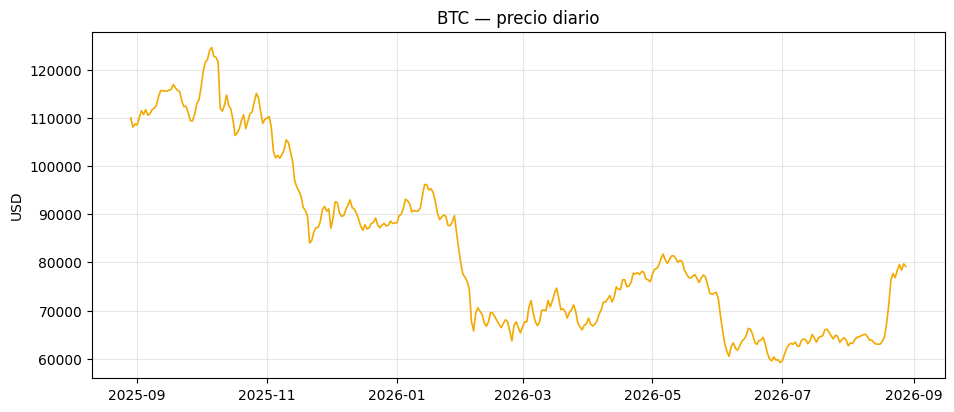

In [4]:
fig, ax = plt.subplots()
ax.plot(df["fecha"], df["precio"], lw=1.2, color="#f2a900")
ax.set_title("BTC — precio diario")
ax.set_ylabel("USD")
ax.grid(alpha=0.3)
plt.show()

### Estacionariedad, autocorrelación y volatilidad

Si el **precio** no es estacionario pero los **retornos logarítmicos** sí, estamos ante un
comportamiento tipo *random walk* — típico en criptoactivos, y la razón técnica de fondo por la
que ningún ajuste determinístico puede "predecir" el futuro con certeza.

In [5]:
precio = df["precio"].values
log_ret = np.diff(np.log(precio))

adf_precio = adfuller(precio)
adf_ret = adfuller(log_ret)

print(f"ADF sobre el precio      -> stat={adf_precio[0]:.3f}  p-valor={adf_precio[1]:.4f}")
print(f"ADF sobre log-retornos   -> stat={adf_ret[0]:.3f}  p-valor={adf_ret[1]:.4f}")

vol_diaria = log_ret.std(ddof=1)
vol_anual = vol_diaria * np.sqrt(365)
print(f"\nVolatilidad diaria (std log-retornos): {vol_diaria:.4f}")
print(f"Volatilidad anualizada aproximada:      {vol_anual:.2%}")

acfs = acf(log_ret, nlags=10)
print("\nAutocorrelación de retornos (lags 1-10):", np.round(acfs[1:], 3))

ADF sobre el precio      -> stat=-1.704  p-valor=0.4292
ADF sobre log-retornos   -> stat=-6.423  p-valor=0.0000

Volatilidad diaria (std log-retornos): 0.0184
Volatilidad anualizada aproximada:      35.22%

Autocorrelación de retornos (lags 1-10): [ 0.35  -0.045 -0.023  0.035  0.074  0.081  0.125 -0.044 -0.167 -0.066]


/tmp/ipykernel_90/2322406692.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_precio = adfuller(precio)
/tmp/ipykernel_90/2322406692.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_ret = adfuller(log_ret)


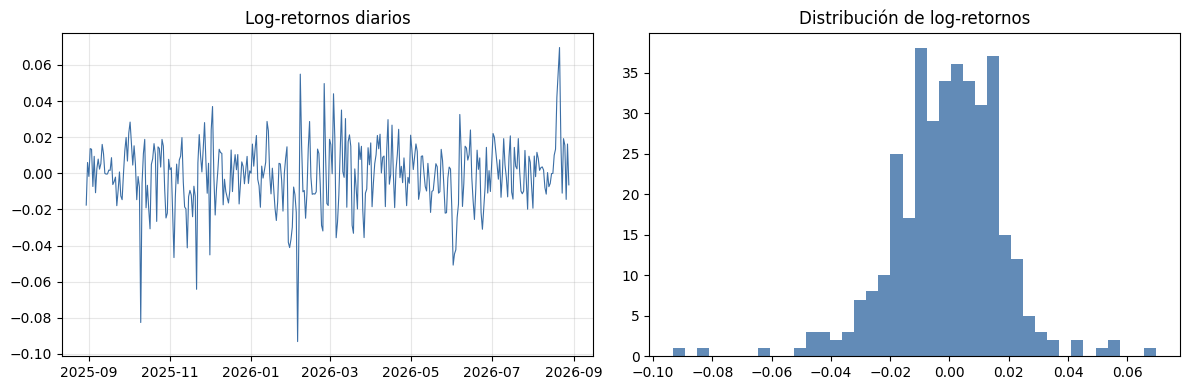

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df["fecha"].iloc[1:], log_ret, lw=0.8, color="#3b6ea5")
axes[0].set_title("Log-retornos diarios")
axes[0].grid(alpha=0.3)
axes[1].hist(log_ret, bins=40, color="#3b6ea5", alpha=0.8)
axes[1].set_title("Distribución de log-retornos")
plt.tight_layout()
plt.show()

**Lectura del diagnóstico:**
- El precio **no es estacionario** (p-valor alto) → una tendencia determinística simple
  (recta/polinomio) no tiene sustento estadístico.
- Los **retornos sí son estacionarios** (p-valor ≈ 0) → la estructura predecible, si existe,
  vive en los retornos de corto plazo, no en el nivel del precio.
- Autocorrelación lag-1 moderada → hay algo de *momentum* de un día para el otro. Ojo: parte de
  esa autocorrelación puede venir de cómo se construye el dato (precio = (máx+mín)/2 promedia
  dentro del día), así que no la tomamos como evidencia fuerte de predictibilidad.
- La volatilidad anualizada resume qué tan ruidosos son los tramos de la serie.

## 2. Metodología de evaluación: Walk-Forward Validation

Ventana expansiva: entrenar con `[0, start)`, pronosticar `horizon` días, comparar contra el
valor real, deslizar `start` y repetir. Los `folds` quedan como una **tupla inmutable** — nadie
en el resto del notebook puede mutarla por accidente.

In [7]:
folds: Tuple[int, ...] = tuple(range(WF.min_train, n_all - WF.horizon + 1, WF.step))
print(f"Número de folds de walk-forward: {len(folds)}")

Número de folds de walk-forward: 30


## 3. Modelo 1 — Ajuste por función lambda (no lineal, no polinomial)

$$f(u) = a_0 + a_1 \tanh\big(a_2 (u - a_3)\big) + \sum_{k=1}^{K} \big[b_k \sin(2\pi k u / P) + c_k \cos(2\pi k u / P)\big]$$

`u = t / n` es el tiempo normalizado. `make_model` es una **función de orden superior**: es una
fábrica que devuelve una función pura (`model`) — un *closure* sobre `period_u` y `harmonics`,
sin ningún estado mutable de por medio.

Para manejar el caso en que `curve_fit` no converge con **ningún** período candidato, en vez de
dejar que el notebook explote con un error críptico (como en la versión anterior) devolvemos un
`FitOutcome`: un registro inmutable de éxito/error con un método `.map()` que **preserva la
forma** — si hubo error, lo propaga sin tocarlo; si hubo éxito, transforma el valor. Es el mismo
patrón Functor de la sección 0, aplicado a un resultado que puede fallar. (Esto anticipa el
patrón **Mónada** — Maybe/Either — que se formaliza recién en la Clase 8; acá nos alcanza con la
mitad Functor.)

In [8]:
class FitOutcome(NamedTuple):
    ok: bool
    value: Optional[Callable] = None
    rmse: Optional[float] = None
    error: Optional[str] = None

    def map(self, f: Callable) -> "FitOutcome":
        '''Functor: transforma `value` sólo si hubo éxito; si no, propaga el error intacto.'''
        return self if not self.ok else FitOutcome(ok=True, value=f(self.value), rmse=self.rmse)


def make_model(period_u: float, harmonics: int) -> Callable:
    '''HOF: fábrica de funciones puras. Cada llamada devuelve un closure nuevo,
    sin compartir estado con las demás.'''
    def model(u, a0, a1, a2, a3, *bc):
        val = a0 + a1 * np.tanh(a2 * (u - a3))
        for k in range(harmonics):
            b, c = bc[2 * k], bc[2 * k + 1]
            w = 2 * np.pi * (k + 1) / period_u
            val = val + b * np.sin(w * u) + c * np.cos(w * u)
        return val
    return model


def fit_lambda_function(t_train: np.ndarray, y_train: np.ndarray, cfg: LambdaConfig = LCFG) -> FitOutcome:
    '''Función pura: misma entrada, mismo resultado; no muta `t_train`/`y_train` ni nada externo.
    Prueba varios períodos candidatos y bounds razonables (evita que curve_fit se vaya a un
    óptimo local absurdo), y se queda con el de menor RMSE in-sample.'''
    n = len(t_train)
    u = t_train / n
    bounds_lo = [-np.inf, -np.inf, 1e-6, -5.0] + [-np.inf, -np.inf] * cfg.harmonics
    bounds_hi = [np.inf, np.inf, 50.0, 5.0] + [np.inf, np.inf] * cfg.harmonics

    def try_period(period_u: float) -> FitOutcome:
        model = make_model(period_u, cfg.harmonics)
        p0 = [y_train.mean(), (y_train.max() - y_train.min()) / 2, 3, 0.5] + [1.0, 1.0] * cfg.harmonics
        try:
            popt, _ = curve_fit(model, u, y_train, p0=p0, bounds=(bounds_lo, bounds_hi), maxfev=40000)
        except (RuntimeError, ValueError) as e:
            # Sólo capturamos fallas de la optimización. Un error de programación
            # (NameError, TypeError...) tiene que explotar a la vista, no esconderse.
            return FitOutcome(ok=False, error=f"P={period_u:.3f}: {type(e).__name__}: {e}")
        rmse = calc_rmse(y_train, model(u, *popt))
        return FitOutcome(ok=True, value=(model, popt), rmse=rmse)

    intentos: Tuple[FitOutcome, ...] = tuple(map(try_period, cfg.periods_u))
    exitos = tuple(filter(lambda o: o.ok, intentos))
    if not exitos:
        detalle = " | ".join(o.error for o in intentos)
        return FitOutcome(ok=False, error=f"curve_fit no convergió con ningún período candidato -> {detalle}")

    mejor = min(exitos, key=lambda o: o.rmse)
    # Functor en acción: transformamos (model, popt) en la función de pronóstico final
    return mejor.map(lambda mp: (lambda t_new: mp[0](np.asarray(t_new, dtype=float) / n, *mp[1])))

Ajuste in-sample -> MAE=2,775  RMSE=3,531  MAPE=3.44%


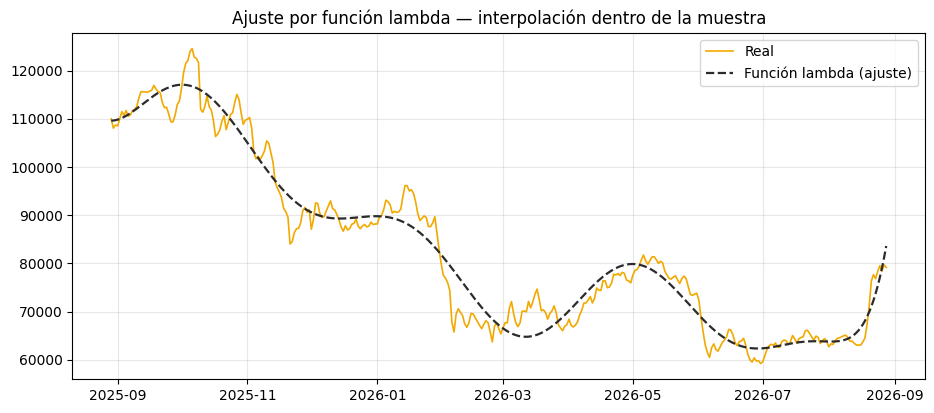

In [9]:
t_all = df["t"].values.astype(float)
y_all = df["precio"].values.astype(float)

fit_in = fit_lambda_function(t_all, y_all)
assert fit_in.ok, fit_in.error
f_lambda = fit_in.value

pred_in_sample = f_lambda(t_all)
mae_in = calc_mae(y_all, pred_in_sample)
rmse_in = calc_rmse(y_all, pred_in_sample)
mape_in = calc_mape(y_all, pred_in_sample)
print(f"Ajuste in-sample -> MAE={mae_in:,.0f}  RMSE={rmse_in:,.0f}  MAPE={mape_in:.2f}%")

fig, ax = plt.subplots()
ax.plot(df["fecha"], y_all, label="Real", lw=1.2, color="#f2a900")
ax.plot(df["fecha"], pred_in_sample, label="Función lambda (ajuste)", lw=1.6, color="#2b2b2b", ls="--")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Ajuste por función lambda — interpolación dentro de la muestra")
plt.show()

### Chequeo honesto: ¿el error bajo "in-sample" se sostiene afuera?

Probamos prediciendo los últimos 30 días **sin haberlos visto** en el ajuste.

Extrapolación out-of-sample (30 días) -> MAE=44,893  RMSE=50,898  MAPE=64.02%
(vs. 3.44% de MAPE in-sample — la diferencia es la señal de alerta importante)


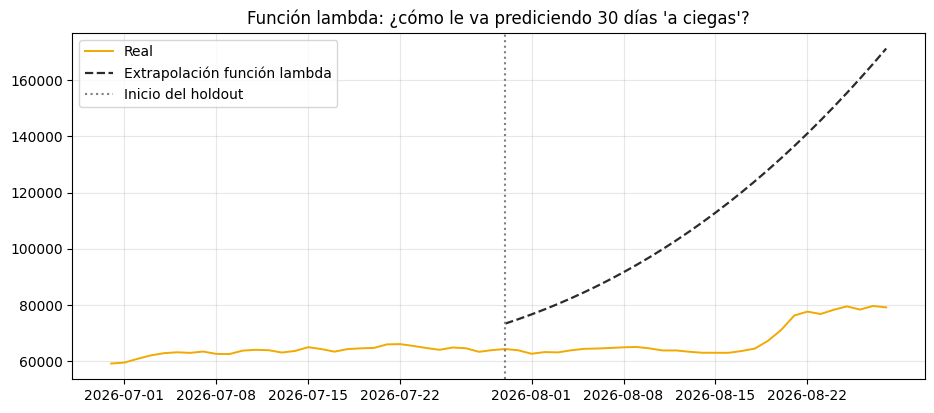

In [10]:
HOLDOUT = 30
t_tr, y_tr = t_all[:-HOLDOUT], y_all[:-HOLDOUT]
t_te, y_te = t_all[-HOLDOUT:], y_all[-HOLDOUT:]

fit_holdout = fit_lambda_function(t_tr, y_tr)
assert fit_holdout.ok, fit_holdout.error
pred_te = fit_holdout.value(t_te)

mae_out = calc_mae(y_te, pred_te)
rmse_out = calc_rmse(y_te, pred_te)
mape_out = calc_mape(y_te, pred_te)
print(f"Extrapolación out-of-sample (30 días) -> MAE={mae_out:,.0f}  RMSE={rmse_out:,.0f}  MAPE={mape_out:.2f}%")
print(f"(vs. {mape_in:.2f}% de MAPE in-sample — la diferencia es la señal de alerta importante)")

fig, ax = plt.subplots()
ax.plot(df["fecha"].iloc[-60:], y_all[-60:], label="Real", lw=1.4, color="#f2a900")
ax.plot(df["fecha"].iloc[-HOLDOUT:], pred_te, label="Extrapolación función lambda", lw=1.6, color="#2b2b2b", ls="--")
ax.axvline(df["fecha"].iloc[-HOLDOUT], color="grey", ls=":", label="Inicio del holdout")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Función lambda: ¿cómo le va prediciendo 30 días 'a ciegas'?")
plt.show()

## 4. Modelo 2 — Estimador Funcional de Ventana Móvil (W=7 días)

Siguiendo lo que nos pidió el profe de no meter Machine Learning, cambiamos el modelo de Gradient Boosting por un estimador clásico de series de tiempo basado en ventana móvil.

La idea es súper simple y funcional: tomamos los precios pasados como una tupla inmutable y armamos una función de orden superior con un closure. Usamos `reduce` para calcular la media aritmética de los últimos 7 días (la última semana observada) y proyectamos ese promedio fijo para los días siguientes.


In [11]:
# Estimador funcional puro de ventana móvil (W=7)
def modelo_naive(historial: Tuple[float, ...], horizonte: int = 7) -> Tuple[float, ...]:
    """Modelo base ingenuo: simplemente asume que mañana el precio será igual al de hoy."""
    return (historial[-1],) * horizonte

def crear_estimador_ventana(w: int) -> Callable[[Tuple[float, ...], int], Tuple[float, ...]]:
    """Closure funcional: promedia los últimos W días usando reduce."""
    def estimador(historial: Tuple[float, ...], horizonte: int = 7) -> Tuple[float, ...]:
        ventana = historial[-w:]
        media = reduce(lambda a, b: a + b, ventana) / float(w)
        return (media,) * horizonte
    return estimador

estimador_w7 = crear_estimador_ventana(w=7)

# Probamos cómo proyecta hoy con los datos completos
precios_tupla: Tuple[float, ...] = tuple(df["precio"].values.astype(float))
print(f"Último precio observado (Base W=1): USD {precios_tupla[-1]:,.2f}")
print(f"Proyección Ventana Móvil (W=7):     USD {estimador_w7(precios_tupla, 7)[0]:,.2f}")


Último precio observado (Base W=1): USD 79,176.55
Proyección Ventana Móvil (W=7):     USD 78,515.01


### ¿Por qué elegimos 7 días?

Elegimos una ventana de $W=7$ días para capturar el promedio de una semana entera y filtrar el ruido diario. La duda que nos queda (y que vamos a comprobar numéricamente en la validación) es si promediar precios viejos de hace una semana no termina jugando en contra frente a Bitcoin, que se mueve muy rápido.


In [12]:
# Verificamos que la función sea pura con una pequeña prueba
muestra_prueba = (100.0, 102.0, 104.0, 106.0, 108.0, 110.0, 112.0)
assert estimador_w7(muestra_prueba, horizonte=3) == (106.0, 106.0, 106.0)
print("Todo bien: el estimador dio la media exacta sin mutar la tupla.")


Todo bien: el estimador dio la media exacta sin mutar la tupla.


## 5. Walk-forward: comparación real entre los modelos

Para no juzgar los modelos con una sola semana de suerte, los evaluamos paso a paso a lo largo de 30 ventanas temporales hacia adelante.

Para ser fieles a funcional, no usamos bucles mutables con listas y `.append()`. Evaluamos cada ventana con `map` y combinamos los resultados inmutables con `reduce` usando el patrón **Monoid** (donde la tupla vacía `()` es el elemento neutro y `+` concatena).


In [13]:
class FoldResult(NamedTuple):
    start: int
    naive_mae: float
    naive_mape: float
    lambda_mae: float
    lambda_mape: float
    ventana_mae: float
    ventana_mape: float

def evaluate_fold(start: int) -> Optional[FoldResult]:
    """Evalúa los tres modelos en una ventana dada sin tocar nada de afuera."""
    t_train = df.loc[:start - 1, "t"].values.astype(float)
    p_train = df.loc[:start - 1, "precio"].values.astype(float)
    p_test  = df.loc[start:start + WF.horizon - 1, "precio"].values.astype(float)
    t_test  = df.loc[start:start + WF.horizon - 1, "t"].values.astype(float)

    if len(p_test) < WF.horizon:
        return None

    # 1. Modelo Base (W=1)
    pred_naive = modelo_naive(tuple(p_train), horizonte=WF.horizon)

    # 2. Función no lineal (Tanh + Fourier)
    fit = fit_lambda_function(t_train, p_train, LCFG)
    if not fit.ok:
        return None
    pred_lambda = fit.value(t_test)

    # 3. Ventana Móvil (W=7)
    pred_ventana = estimador_w7(tuple(p_train), horizonte=WF.horizon)

    p_test_arr = np.array(p_test)
    return FoldResult(
        start=start,
        naive_mae=calc_mae(p_test_arr, np.array(pred_naive)),
        naive_mape=calc_mape(p_test_arr, np.array(pred_naive)),
        lambda_mae=calc_mae(p_test_arr, np.array(pred_lambda)),
        lambda_mape=calc_mape(p_test_arr, np.array(pred_lambda)),
        ventana_mae=calc_mae(p_test_arr, np.array(pred_ventana)),
        ventana_mape=calc_mape(p_test_arr, np.array(pred_ventana)),
    )

# Acumulación con reduce (patrón Monoid puro)
results_tuple: Tuple[FoldResult, ...] = reduce(
    lambda acc, x: acc + ((x,) if x is not None else ()),
    map(evaluate_fold, folds),
    ()
)

res = pd.DataFrame([r._asdict() for r in results_tuple])
print(f"Evaluamos con éxito {len(res)} ventanas de 7 días cada una.")


Evaluamos con éxito 30 ventanas de 7 días cada una.


                                  MAE promedio (USD)  MAPE promedio (%)
Modelo Base (W=1)                            2392.70               3.44
Ventana Móvil (W=7)                          2899.27               4.16
Función No Lineal (Tanh+Fourier)             7038.21              10.35


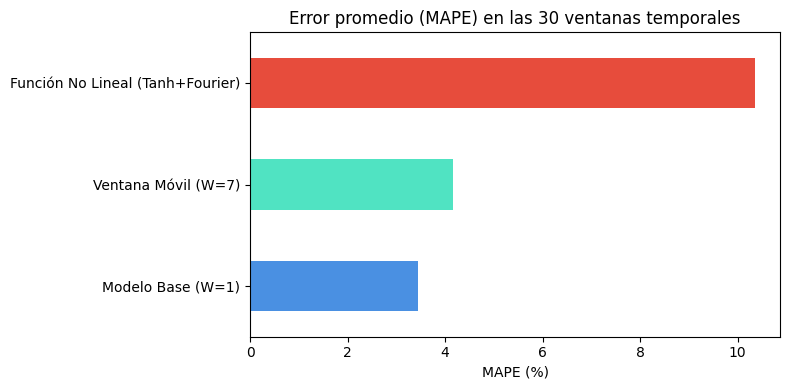

In [14]:
tabla = pd.DataFrame({
    "MAE promedio (USD)": [res.naive_mae.mean(), res.ventana_mae.mean(), res.lambda_mae.mean()],
    "MAPE promedio (%)": [res.naive_mape.mean(), res.ventana_mape.mean(), res.lambda_mape.mean()],
}, index=["Modelo Base (W=1)", "Ventana Móvil (W=7)", "Función No Lineal (Tanh+Fourier)"])
print(tabla.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
tabla["MAPE promedio (%)"].plot(kind="barh", color=["#4A90E2", "#50E3C2", "#E74C3C"], ax=ax)
ax.set_title("Error promedio (MAPE) en las 30 ventanas temporales")
ax.set_xlabel("MAPE (%)")
plt.tight_layout()
plt.show()


### ¿La diferencia entre los modelos es real o casualidad?

Mirar solo el promedio a veces engaña. Como cada ventana se evaluó exactamente sobre los mismos días en los tres modelos, corresponde usar una prueba estadística pareada: el **test de Wilcoxon** sobre los errores de cada fold.


In [15]:
stat_ventana, p_ventana = wilcoxon(res["naive_mape"], res["ventana_mape"])
stat_lambda, p_lambda = wilcoxon(res["naive_mape"], res["lambda_mape"])

print(f"Wilcoxon (Base W=1 vs. Ventana W=7): p = {p_ventana:.4f}")
print(f"Wilcoxon (Base W=1 vs. No Lineal):   p = {p_lambda:.4e}")


Wilcoxon (Base W=1 vs. Ventana W=7): p = 0.0473
Wilcoxon (Base W=1 vs. No Lineal):   p = 7.9945e-06


**¿Qué significa este resultado?**
- **Base vs. Ventana Móvil ($p = 0,0473$):** Como $p < 0,05$, la diferencia es estadísticamente significativa. El modelo base (3,44 %) le gana a la ventana de 7 días (4,16 %). Esto tiene todo el sentido: al ser Bitcoin un paseo aleatorio, promediar precios de hace una semana arrastra un retraso (*inercia*) que hace perder precisión frente al dato más inmediato de ayer.
- **Base vs. Función No Lineal ($p < 0,0001$):** La curva rígida pierde por goleada (10,35 % promedio) porque no tiene forma de adaptarse a los giros del mercado local.


## 6. Proyección final hacia el futuro (30 días)

Por último, calibramos los modelos con todo el año disponible (los 365 días) y miramos qué proyectan para los próximos 30 días:

- **Modelo Base (W=1):** Traza una línea horizontal en el último precio observado (USD 79.176,55).
- **Ventana Móvil (W=7):** Traza una línea horizontal en el promedio de la última semana (USD 78.515,01).
- **Función No Lineal:** Proyecta la curva matemática hacia adelante.
- **Cono de incertidumbre ($\pm 2\sigma$):** Calculamos la volatilidad diaria de los retornos para graficar el rango esperable de un paseo aleatorio hacia el futuro. Está centrado en el último precio, así que el modelo base queda adentro por construcción.

*Los valores de las etiquetas del gráfico se calculan en la celda, no están escritos a mano.*


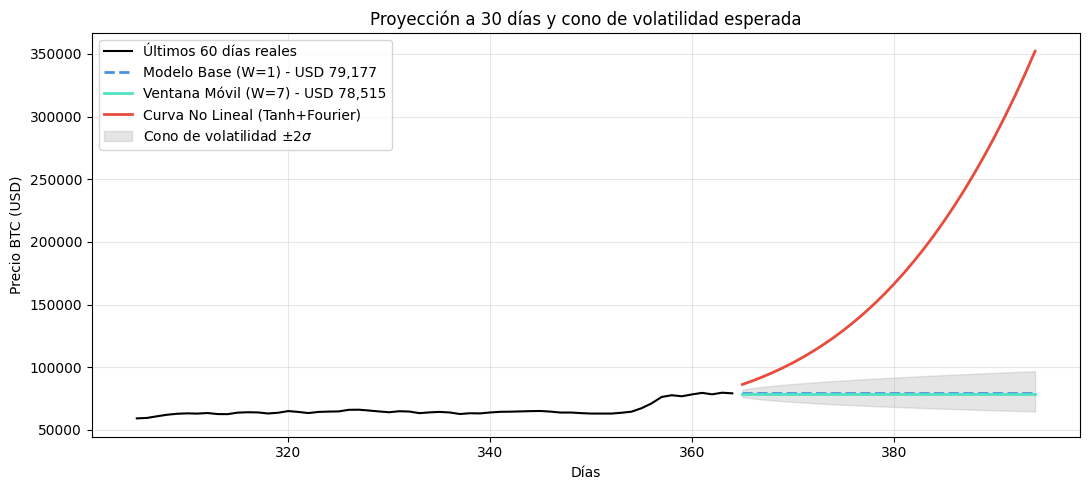

Modelo Base (W=1):     USD 79,176.55
Ventana Móvil (W=7):   USD 78,515.01
Función No Lineal:     USD 86,249.93 (día 1) -> USD 352,181.91 (día 30)


In [16]:
FUTURE_DAYS = 30
precios = df['precio'].values.astype(float)
t_all = df['t'].values.astype(float)
ultimo_precio = precios[-1]

# Proyecciones futuras
proy_naive = np.full(FUTURE_DAYS, ultimo_precio)
proy_w7 = np.array(estimador_w7(tuple(precios), horizonte=FUTURE_DAYS))

fit_full = fit_lambda_function(t_all, precios, LCFG)
assert fit_full.ok, fit_full.error
t_fut = np.arange(len(precios), len(precios) + FUTURE_DAYS)
proy_lambda = fit_full.value(t_fut)

# Cono estocástico (+/- 2 desvíos estándar)
log_rets = np.diff(np.log(precios))
sigma_diaria = np.std(log_rets)
h_steps = np.arange(1, FUTURE_DAYS + 1)
banda_sup = ultimo_precio * np.exp(2 * sigma_diaria * np.sqrt(h_steps))
banda_inf = ultimo_precio * np.exp(-2 * sigma_diaria * np.sqrt(h_steps))

plt.figure(figsize=(11, 5))
plt.plot(range(len(precios)-60, len(precios)), precios[-60:], label="Últimos 60 días reales", color="black", lw=1.5)
plt.plot(t_fut, proy_naive, label=f"Modelo Base (W=1) - USD {proy_naive[0]:,.0f}", color="#4A90E2", lw=2, linestyle="--")
plt.plot(t_fut, proy_w7, label=f"Ventana Móvil (W=7) - USD {proy_w7[0]:,.0f}", color="#50E3C2", lw=2)
plt.plot(t_fut, proy_lambda, label="Curva No Lineal (Tanh+Fourier)", color="#E74C3C", lw=2)
plt.fill_between(t_fut, banda_inf, banda_sup, color="gray", alpha=0.2, label=r"Cono de volatilidad $\pm 2\sigma$")
plt.title("Proyección a 30 días y cono de volatilidad esperada")
plt.xlabel("Días")
plt.ylabel("Precio BTC (USD)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Modelo Base (W=1):     USD {proy_naive[0]:,.2f}")
print(f"Ventana Móvil (W=7):   USD {proy_w7[0]:,.2f}")
print(f"Función No Lineal:     USD {proy_lambda[0]:,.2f} (día 1) -> USD {proy_lambda[-1]:,.2f} (día {FUTURE_DAYS})")


## 7. Cómo probar los modelos con nuevos datos

Si tuviéramos un dato nuevo de mañana, los modelos se usan así de fácil:
- `modelo_naive(historial, h)`: toma la tupla y proyecta el último valor.
- `estimador_w7(historial, h)`: calcula el promedio de los últimos 7 días con `reduce`.
- `fit_full.value(t)`: evalúa la fórmula matemática en cualquier día futuro `t`.


In [17]:
print("Probando los estimadores:")
print(f"1. Pronóstico Base a 3 días:    {modelo_naive(tuple(precios[-10:]), horizonte=3)}")
print(f"2. Pronóstico Ventana a 3 días: {estimador_w7(tuple(precios[-10:]), horizonte=3)}")
if fit_full.ok:
    print(f"3. Curva matemática en día {len(precios)}: USD {fit_full.value(len(precios)):,.2f}")


Probando los estimadores:
1. Pronóstico Base a 3 días:    (np.float64(79176.55), np.float64(79176.55), np.float64(79176.55))
2. Pronóstico Ventana a 3 días: (np.float64(78515.00714285715), np.float64(78515.00714285715), np.float64(78515.00714285715))
3. Curva matemática en día 365: USD 86,249.93


## 8. Lo que aprendimos de este trabajo

1. **En series financieras, lo simple muchas veces gana:** El test de Dickey-Fuller nos demostró que el precio no es estacionario pero los retornos sí (ruido blanco). En este escenario, mirar sólo el último precio ($W=1$) le ganó con significancia estadística a promediar 7 días ($p = 0,0473$) porque promediar el pasado te arrastra hacia atrás.
2. **El peligro de sobreajustar:** La función no lineal con Fourier parecía excelente adentro de la muestra, pero al proyectar hacia adelante se descontroló completamente (64 % de error). No por ser una fórmula más compleja va a predecir mejor.
3. **Programación funcional en la práctica:** Logramos armar todo el pipeline de punta a punta respetando los conceptos vistos en clase: inmutabilidad con tuplas, closures puros con `reduce`, la estructura `FitOutcome` con `.map()` y la verificación matemática de las dos leyes de Functor con `assert`.
